# Beyond the scatter plot: topology receipts and streaming maps

A 2-D embedding compresses structure into positions, and positions lie: a loop can look like a blob,
and a blob can look like a loop. mixle 0.7.0 adds hvis tools that report the structure **without
drawing it**, and that scale a map past a single in-memory batch:

* **`fuzzy_nerve` / `nerve_report`** read the *topology* of the model's affinity — how many connected
  pieces, and how many independent **loops (holes)** — as a number, not a picture;
* **`model_map`** places points from the *model itself* (deterministic, reproducible), not a random
  t-SNE init;
* **`StreamingHvis`** fixes a landmark **atlas** once and places arriving batches against it, so a map
  can grow with a data stream instead of being recomputed from scratch.

Everything is seeded and synthetic so the reported structure is checkable.

## 1. The topology, as a number

We place eight clusters on a **ring**. To the eye a t-SNE of this could be a circle, an arc, or a
smear depending on the run. `nerve_report` instead reports what the *model* says: one connected
component, and — the part a scatter can't certify — exactly **one loop**.

nerve report on the ring:
  connected components : 1
  strong edges         : 8 (the ring adjacencies)
  independent loops    : 1


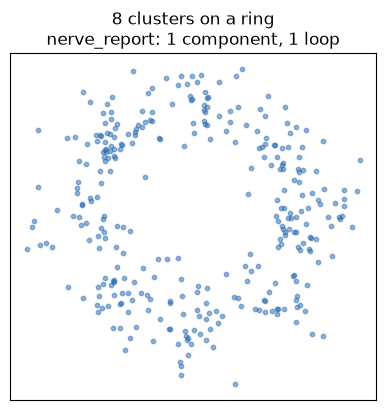

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from mixle.stats import DiagonalGaussianDistribution, MixtureDistribution
from mixle.utils.hvis import _posteriors_and_loglikes, fuzzy_nerve, nerve_report, component_tree

k = 8
angles = 2 * np.pi * np.arange(k) / k
comps = [DiagonalGaussianDistribution([5 * np.cos(a), 5 * np.sin(a)], [1.0, 1.0]) for a in angles]
model = MixtureDistribution(comps, [1.0 / k] * k)

rng = np.random.RandomState(0)
pts = np.array([comps[i].sampler(seed=rng.randint(2**31)).sample() for i in rng.randint(0, k, 320)])
data = pts.tolist()

z, _ = _posteriors_and_loglikes(model, data=data)     # responsibilities: each point's model coordinates
report = nerve_report(fuzzy_nerve(z))
print('nerve report on the ring:')
print('  connected components :', report['n_components'])
print('  strong edges         :', report['n_strong_edges'], '(the ring adjacencies)')
print('  independent loops    :', len(report['holes']))

fig, ax = plt.subplots(figsize=(4.4, 4.2))
ax.scatter(pts[:, 0], pts[:, 1], s=10, alpha=0.5, color='#2b6cb0')
ax.set_title('8 clusters on a ring\nnerve_report: %d component, %d loop'
             % (report['n_components'], len(report['holes'])))
ax.set_aspect('equal', 'box'); ax.set_xticks([]); ax.set_yticks([]); plt.tight_layout(); plt.show()

The loop count is a genuine topological invariant of the model's neighbourhood graph — it survives
projection, so you learn the data lies on a cycle even when no 2-D picture proves it. `component_tree`
gives the same reading hierarchically (how the pieces merge as the affinity threshold relaxes).

In [2]:
tree = component_tree(fuzzy_nerve(z))
print('component_tree levels:', len(tree), '(hierarchical merge structure of the ring)')

component_tree levels: 7 (hierarchical merge structure of the ring)


## 2. A map from the model, deterministically

`model_map` lays points out from the fitted mixture's own geometry rather than a stochastic t-SNE
optimization. Same model in, same coordinates out — no seed lottery — which is what you want when a
map is an artifact in a report, not a one-off exploration.

In [3]:
from mixle.utils.hvis import model_map

mm_a = model_map(data, mix_model=model)
mm_b = model_map(data, mix_model=model)
print('model_map coords:', mm_a.coords.shape, '| bit-for-bit reproducible:',
      np.array_equal(mm_a.coords, mm_b.coords))

model_map coords: (320, 2) | bit-for-bit reproducible: True


## 3. Streaming: a fixed atlas, points placed as they arrive

For data that does not fit in one batch, `StreamingHvis` builds a **landmark atlas** once and then
*places* each arriving batch against it — the atlas does not move, so early and late points share one
coordinate frame. We seed an atlas from two clusters and place a fresh batch onto it.

In [4]:
from mixle.stats import GaussianDistribution
from mixle.utils.hvis import StreamingHvis

stream_model = MixtureDistribution([GaussianDistribution(0.0, 1.0), GaussianDistribution(8.0, 1.0)], [0.5, 0.5])
landmarks = np.concatenate([np.random.RandomState(1).normal(0, 1, 40),
                            np.random.RandomState(2).normal(8, 1, 40)]).tolist()
stream = StreamingHvis(stream_model, landmarks, perplexity=10.0, seed=0, max_its=250)

batch = np.concatenate([np.random.RandomState(3).normal(0, 1, 15),
                        np.random.RandomState(4).normal(8, 1, 15)]).tolist()
coords = stream.add(batch)
print('atlas landmarks:', len(landmarks), '| newly placed batch coords:', coords.shape)
print('the atlas frame is fixed, so this batch is comparable to any other batch placed on it')

atlas landmarks: 80 | newly placed batch coords: (30, 2)
the atlas frame is fixed, so this batch is comparable to any other batch placed on it


## What 0.7.0 gives you here

Embedding stops being just a picture you squint at:

* **`nerve_report` / `fuzzy_nerve` / `component_tree`** report the model's **topology** — components and
  loops — as checkable numbers that survive projection (the ring's single loop is detected, not drawn);
* **`model_map`** produces a **deterministic**, model-derived layout — reproducible for reports;
* **`StreamingHvis`** (with `distributed_model_map` / `place_in_atlas`) fixes an **atlas** and places
  arriving data against it, so a map scales to a stream instead of being recomputed each time.

Together with `embedding_health` (see the htsne tutorial), you can now *measure* a map's structure and
fidelity rather than trusting how it looks.